In [1]:
%load_ext autoreload
%autoreload 2
%xmode verbose

Exception reporting mode: Verbose


In [ ]:
from astroquery.nasa_exoplanet_archive import NasaExoplanetArchive

# Query all confirmed exoplanets
table = NasaExoplanetArchive.query_criteria(
    table = 'PS',
    select = 'pl_name, pl_bmasse, pl_rade, disc_year, pl_controv_flag'
)

# Convert to pandas DataFrame
data = table.to_pandas()

# Display or save to CSV
data.to_csv('exoplanet_data.csv')

In [2]:
import pandas

data = pandas.read_csv('exoplanet_data.csv')
data = data[data['pl_controv_flag'] == 0]
data['radius'] = data['pl_rade']
data['mass'] = data['pl_bmasse']

data = data[data['radius'].notna() & data['mass'].notna()]
# data = data.drop_duplicates(subset = 'pl_name')
# data = data.drop_duplicates(subset = 'pl_rade')

data = data.sort_values(by = ['pl_name', 'disc_year'], ascending = [True, False])
data = data.drop_duplicates(subset = 'pl_name').reset_index(drop = True)

rm = data[['radius', 'mass']]
rm.to_csv('exoplanet_rm.csv', index = False)

In [9]:
import pandas
import matplotlib.pyplot as plot
import numpy

data = pandas.read_csv('exoplanet_rm.csv')

data = data[['radius', 'mass']].dropna().reset_index(drop = True)
data = data.sort_values('radius').reset_index(drop = True)

counts = []
result = []
for i in range(len(data['radius'])):
    while data.loc[i, 'radius'] in counts:
        data.loc[i, 'radius'] += 1e-6

    counts.append(data.loc[i, 'radius'])

data = data.sort_values('radius').reset_index(drop = True)
# data = data.drop_duplicates('radius')
data = data.reset_index(drop = True)
data

,radius,mass
0,0.320000,10.00000
1,0.470000,4.30000
2,0.500000,0.20000
3,0.500001,0.10000
4,0.510000,99.20000
...,...,...
1504,23.370765,108.06220
1505,23.538859,375.03752
1506,24.660000,5403.00000
1507,30.264300,3496.13000


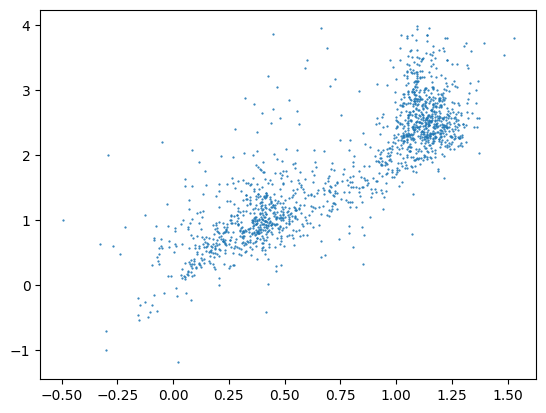

In [10]:
x = data['radius']
y = data['mass']

# mask = x < numpy.percentile(x, 99.9)

x = numpy.log10(x)
y = numpy.log10(y)

plot.scatter(x, y, s = 0.3)
# plot.loglog()
plot.show()

0.23882388238823882 1.648964896489649


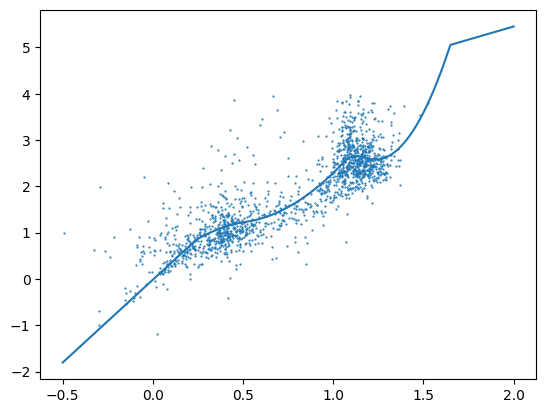

In [11]:
from scipy.interpolate import UnivariateSpline
model = UnivariateSpline(x, y, k = 2, s = 335)

from LogRMModel import LogRMModel
model = LogRMModel(model, x, y)

x_smooth = numpy.linspace(-0.5, 2, 10000)
y_smooth = model(x_smooth)

min_crossing = x_smooth[numpy.argmin(numpy.abs(y_smooth - (1 / 0.279) * numpy.log10((10 ** x_smooth) / 1.008)))]
max_crossing = x_smooth[numpy.argmin(numpy.abs(y_smooth - (1 / 0.881) * numpy.log10((10 ** x_smooth) / 0.00157)))]

model.override_min(min_crossing, model(min_crossing))
model.override_max(max_crossing, model(max_crossing))
print(min_crossing, max_crossing)
y_smooth = model(x_smooth)

plot.scatter(x, y, s = 0.3)
plot.plot(x_smooth, y_smooth)
plot.show()

In [ ]:
import pickle

with open('radius_mass_model.pkl', 'wb') as file:
    pickle.dump(model, file)

Log Min: -0.5, -1.8045180362347901
Log Max: 2.0, 5.453008340057623
Log Error: 0.47131646480389655


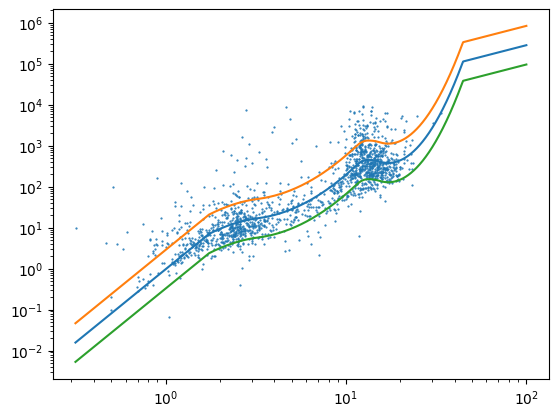

In [ ]:
import pickle
import matplotlib.pyplot as plot
import numpy

with open('radius_mass_model.pkl', 'rb') as file:
    spline = pickle.load(file)

x_smooth = numpy.linspace(-0.5, 2, 10000)
y_smooth = model.predict(x_smooth)

print(f'Log Min: {x_smooth[numpy.argmin(y_smooth)]}, {numpy.min(y_smooth)}')
print(f'Log Max: {x_smooth[numpy.argmax(y_smooth)]}, {numpy.max(y_smooth)}')
print(f'Log Error: {model.error}')

# y_smooth[x_smooth < x_smooth[numpy.argmin(y_smooth)]] = y_smooth[numpy.argmin(y_smooth)]
# y_smooth[x_smooth > x_smooth[numpy.argmax(y_smooth)]] = y_smooth[numpy.argmax(y_smooth)]

# plot.scatter(x, y, s = 0.3)
# plot.plot(x_smooth, y_smooth)
# plot.plot(numpy.linspace(numpy.min(x_smooth), numpy.max(x_smooth), 10), numpy.linspace(numpy.log10(4130), numpy.log10(4130), 10))

plot.plot(numpy.power(10, x_smooth), numpy.power(10, y_smooth))
plot.plot(numpy.power(10, x_smooth), numpy.power(10, y_smooth + model.error))
plot.plot(numpy.power(10, x_smooth), numpy.power(10, y_smooth - model.error))
plot.scatter(numpy.power(10, x), numpy.power(10, y), s = 0.3)

plot.loglog()
# plot.plot(x_smooth, y_smooth)
# plot.xlim(0, 25)
# plot.yscale('log')
plot.show()